# 06 — Baseline Modeling
Train 8 baseline classifiers on both Feature Set A (benchmark) and Feature Set B (realistic), compare them, and identify the best model per metric. Primary metric: **PR-AUC** (Average Precision).

In [8]:
import sys, warnings, time
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (RAW_DIR, TARGET_COL, RANDOM_SEED,
                        FEATURE_SET_A_COLS, FEATURE_SET_B_COLS,
                        NUMERIC_COLS, NUMERIC_COLS_SET_B,
                        MODELS_DIR, REPORTS_DIR)
from src.data_loader import load_dataset
from src.features import encode_target, add_features, get_feature_lists
from src.preprocessing import build_preprocessing_pipeline, split_data
from src.modeling import get_baseline_models, train_model, save_model
from src.evaluation import (evaluate_binary_classifier, save_metrics_csv,
                             plot_roc_curve, plot_pr_curve, plot_confusion_matrix,
                             plot_model_comparison)
from src.utils import ensure_dir

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
ensure_dir(MODELS_DIR)
ensure_dir(REPORTS_DIR)

# ── Load & prep ──────────────────────────────────────────────────────────────
df = load_dataset(RAW_DIR / "bank-additional-full.csv")
df = encode_target(df, TARGET_COL)
df = add_features(df)
X_train, X_test, y_train, y_test = split_data(df, TARGET_COL, random_state=RANDOM_SEED)
print(f"Train {X_train.shape}  |  Test {X_test.shape}  |  Positive rate {y_train.mean():.3f}")

2026-05-17 03:21:25 | INFO     | src.data_loader | Loaded bank-additional-full.csv — shape (41188, 21)
2026-05-17 03:21:25 | INFO     | src.features | Encoded target 'y' → 0/1 (41188 rows).
2026-05-17 03:21:25 | INFO     | src.features | add_features: added 9 engineered features.
2026-05-17 03:21:25 | INFO     | src.preprocessing | split_data: train=32950, test=8238 (stratified, test_size=20%)


Train (32950, 29)  |  Test (8238, 29)  |  Positive rate 0.113


In [9]:
import importlib, src.modeling as _m, src.evaluation as _e
importlib.reload(_m); importlib.reload(_e)
from src.modeling import get_baseline_models, train_model
from src.evaluation import evaluate_binary_classifier, save_metrics_csv
print("Modules reloaded")

Modules reloaded


## 1 — Train All Baselines (Feature Set B — No Duration)
We train on the **Realistic Business Model** first (Feature Set B). ⏳ This takes ~1–2 min.

In [10]:
lists_b = get_feature_lists(df, TARGET_COL, exclude_duration=True)
preprocessor_b = build_preprocessing_pipeline(lists_b["numeric"], lists_b["categorical"])

models = get_baseline_models(random_state=RANDOM_SEED)
results_b = {}

for name, model in models.items():
    t0 = time.time()
    fitted_pipeline, cv_scores = train_model(model, X_train[lists_b["numeric"] + lists_b["categorical"]],
                                              y_train, preprocessor_b)
    elapsed = time.time() - t0
    metrics = evaluate_binary_classifier(fitted_pipeline,
                                          X_test[lists_b["numeric"] + lists_b["categorical"]], y_test)
    metrics.update({"model": name, "feature_set": "set_b",
                    "cv_pr_auc_mean": cv_scores["cv_average_precision_mean"],
                    "cv_pr_auc_std": cv_scores["cv_average_precision_std"],
                    "train_time_s": round(elapsed, 2)})
    results_b[name] = {"pipeline": fitted_pipeline, "metrics": metrics}
    print(f"  {name:<35}  PR-AUC={metrics['average_precision']:.4f}  ROC-AUC={metrics['roc_auc']:.4f}  ({elapsed:.1f}s)")


2026-05-17 03:21:25 | INFO     | src.modeling | XGBClassifier added.
2026-05-17 03:21:25 | INFO     | src.modeling | LGBMClassifier added.
2026-05-17 03:21:25 | INFO     | src.modeling | CatBoostClassifier added.
2026-05-17 03:21:26 | INFO     | src.modeling | Trained DummyClassifier — CV PR-AUC=0.1126 ± 0.0014


  DummyClassifier                      PR-AUC=0.1137  ROC-AUC=0.5051  (0.7s)


2026-05-17 03:21:37 | INFO     | src.modeling | Trained LogisticRegression — CV PR-AUC=0.4370 ± 0.0107


  LogisticRegression                   PR-AUC=0.4558  ROC-AUC=0.7969  (10.4s)


2026-05-17 03:21:39 | INFO     | src.modeling | Trained DecisionTreeClassifier — CV PR-AUC=0.1818 ± 0.0049


...

  XGBClassifier                        PR-AUC=0.4529  ROC-AUC=0.7891  (2.8s)


2026-05-17 03:22:50 | INFO     | src.modeling | Trained LGBMClassifier — CV PR-AUC=0.4641 ± 0.0199


  LGBMClassifier                       PR-AUC=0.4907  ROC-AUC=0.8097  (2.3s)


2026-05-17 03:23:20 | INFO     | src.modeling | Trained CatBoostClassifier — CV PR-AUC=0.4462 ± 0.0175


  CatBoostClassifier                   PR-AUC=0.4871  ROC-AUC=0.8092  (30.0s)


## 2 — Model Comparison Table (Feature Set B)

In [11]:
metrics_rows_b = [v["metrics"] for v in results_b.values()]
df_metrics_b = pd.DataFrame(metrics_rows_b).set_index("model")

display_cols = ["average_precision", "roc_auc", "f1", "precision", "recall",
                "cv_pr_auc_mean", "cv_pr_auc_std", "train_time_s"]
display_cols = [c for c in display_cols if c in df_metrics_b.columns]

styled = (df_metrics_b[display_cols]
          .sort_values("average_precision", ascending=False)
          .style
          .highlight_max(subset=["average_precision", "roc_auc", "f1"], color="#d4edda")
          .format("{:.4f}", subset=[c for c in display_cols if c != "train_time_s"])
          .format("{:.2f}s", subset=["train_time_s"]))
display(styled)

,average_precision,roc_auc,f1,precision,recall,cv_pr_auc_mean,cv_pr_auc_std,train_time_s
model,,,,,,,,
HistGradientBoostingClassifier,0.4975,0.8164,0.5044,0.4122,0.6498,0.4654,0.0230,4.07s
LGBMClassifier,0.4907,0.8097,0.5077,0.4145,0.6552,0.4641,0.0199,2.32s
GradientBoostingClassifier,0.4887,0.8130,0.3435,0.6827,0.2295,0.4614,0.0173,28.87s
CatBoostClassifier,0.4871,0.8092,0.4919,0.3999,0.6390,0.4462,0.0175,30.03s
LogisticRegression,0.4558,0.7969,0.4500,0.3442,0.6498,0.4370,0.0107,10.43s
XGBClassifier,0.4529,0.7891,0.4672,0.3802,0.6056,0.4142,0.0224,2.81s
RandomForestClassifier,0.4306,0.7852,0.3816,0.5581,0.2899,0.4051,0.0123,13.61s
KNeighborsClassifier,0.3535,0.7486,0.4117,0.5603,0.3254,0.3105,0.0156,1.59s
ExtraTreesClassifier,0.3392,0.7517,0.3796,0.4810,0.3136,0.3243,0.0096,17.20s


## 3 — ROC & PR Curves for Top 3 Models (Set B)

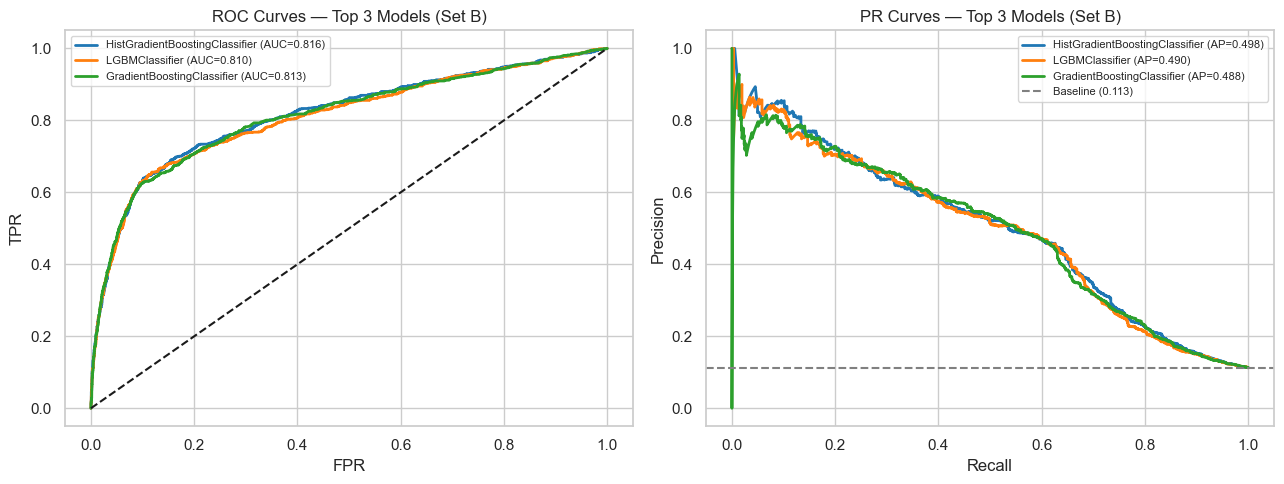

In [12]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

top3 = df_metrics_b["average_precision"].sort_values(ascending=False).head(3).index.tolist()
X_test_b = X_test[lists_b["numeric"] + lists_b["categorical"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for color, name in zip(colors, top3):
    pipeline = results_b[name]["pipeline"]
    y_proba = pipeline.predict_proba(X_test_b)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={roc_auc_val:.3f})")

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc_val = auc(rec, prec)
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{name} (AP={pr_auc_val:.3f})")

axes[0].plot([0, 1], [0, 1], "k--"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curves — Top 3 Models (Set B)"); axes[0].legend(fontsize=8)

baseline = y_test.mean()
axes[1].axhline(baseline, color="gray", linestyle="--", label=f"Baseline ({baseline:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curves — Top 3 Models (Set B)"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4 — Confusion Matrices for Top 3 Models

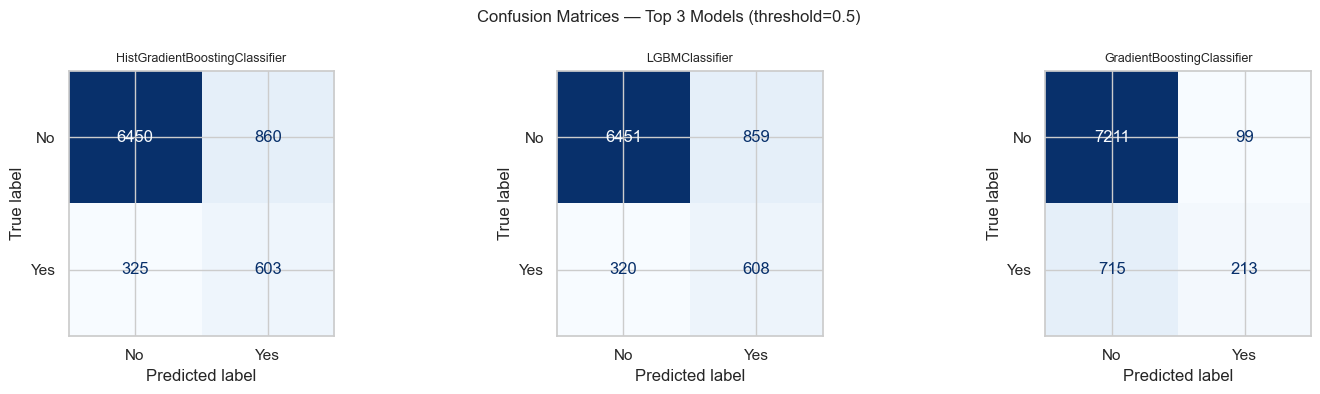

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, top3):
    pipeline = results_b[name]["pipeline"]
    y_pred = pipeline.predict(X_test_b)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=9)

plt.suptitle("Confusion Matrices — Top 3 Models (threshold=0.5)", fontsize=12)
plt.tight_layout()
plt.show()

## 5 — Save Metrics CSV & Best Model

In [14]:
metrics_path = REPORTS_DIR / "model_metrics_notebook.csv"
all_metrics = [v["metrics"] for v in results_b.values()]
pd.DataFrame(all_metrics).to_csv(metrics_path, index=False)
print(f"Metrics saved → {metrics_path}")

# Save best model
best_name = df_metrics_b["average_precision"].idxmax()
best_pipeline = results_b[best_name]["pipeline"]
best_path = MODELS_DIR / "best_model_set_b_notebook.joblib"
save_model(best_pipeline, best_path)
print(f"\n🏆 Best model (Set B): {best_name}")
print(f"   PR-AUC  = {df_metrics_b.loc[best_name, 'average_precision']:.4f}")
print(f"   ROC-AUC = {df_metrics_b.loc[best_name, 'roc_auc']:.4f}")
print(f"   Saved → {best_path}")

2026-05-17 03:23:21 | INFO     | src.modeling | Saved model → /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/models/best_model_set_b_notebook.joblib


Metrics saved → /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/reports/model_metrics_notebook.csv

🏆 Best model (Set B): HistGradientBoostingClassifier
   PR-AUC  = 0.4975
   ROC-AUC = 0.8164
   Saved → /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/models/best_model_set_b_notebook.joblib


## 6 — Imbalanced Data Handling

The dataset has a **severe class imbalance** (~11% positive rate). We compare five resampling strategies applied to the **best baseline model** to see whether balancing improves PR-AUC.

| Strategy | Description |
|---------|-------------|
| `none` | No resampling — relies on `class_weight='balanced'` inside the model |
| `random_over` | Duplicate minority samples until balanced |
| `random_under` | Drop majority samples until balanced |
| `smote_tomek` | SMOTE oversampling + Tomek link removal (hybrid) |
| `smote` | SMOTE — synthetic minority samples via KNN interpolation |

In [15]:
from src.imbalance import compare_resampling_strategies, get_resampler
from sklearn.base import clone

# Use the best baseline model (unfitted clone) as the classifier factory
best_base_model = clone(models[best_name])
classifier_factory = lambda: clone(best_base_model)

feature_cols_b = lists_b["numeric"] + lists_b["categorical"]
X_train_b = X_train[feature_cols_b]
X_test_b_imb = X_test[feature_cols_b]

# Ensure y is integer 0/1 (required by imbalance module)
y_train_int = y_train.astype(int)
y_test_int  = y_test.astype(int)

strategies = ["none", "random_over", "random_under", "smote", "smote_tomek"]

print(f"Comparing imbalance strategies using: {best_name}")
print(f"Class distribution — train: {y_train_int.value_counts().to_dict()}\n")

imbalance_df = compare_resampling_strategies(
    X_train_b, y_train_int, X_test_b_imb, y_test_int,
    preprocessor=clone(preprocessor_b),
    classifier_factory=classifier_factory,
    strategies=strategies,
    n_jobs=1,
)
display(imbalance_df[["strategy", "cv_pr_auc_mean", "cv_pr_auc_std",
                        "cv_roc_auc_mean", "test_pr_auc", "test_roc_auc",
                        "elapsed_s", "error"]].sort_values("test_pr_auc", ascending=False))

2026-05-17 03:48:04 | INFO     | src.imbalance | Evaluating resampling strategy: none


Comparing imbalance strategies using: HistGradientBoostingClassifier
Class distribution — train: {0: 29238, 1: 3712}



2026-05-17 03:48:04 | INFO     | src.imbalance | No resampling — building plain sklearn Pipeline.
2026-05-17 03:48:10 | INFO     | src.imbalance |   none → CV PR-AUC=0.4694  Test PR-AUC=0.4975
2026-05-17 03:48:10 | INFO     | src.imbalance | Evaluating resampling strategy: random_over
2026-05-17 03:48:10 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='random_over'.
2026-05-17 03:48:22 | INFO     | src.imbalance |   random_over → CV PR-AUC=0.4542  Test PR-AUC=0.4949
2026-05-17 03:48:22 | INFO     | src.imbalance | Evaluating resampling strategy: random_under
2026-05-17 03:48:22 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='random_under'.
2026-05-17 03:48:30 | INFO     | src.imbalance |   random_under → CV PR-AUC=0.4374  Test PR-AUC=0.4735
2026-05-17 03:48:30 | INFO     | src.imbalance | Evaluating resampling strategy: smote
2026-05-17 03:48:30 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='smote'.
2026-05-17 0

,strategy,cv_pr_auc_mean,cv_pr_auc_std,cv_roc_auc_mean,test_pr_auc,test_roc_auc,elapsed_s,error
0,none,0.4694,0.0153,0.7964,0.4975,0.8164,6.0,
1,random_over,0.4542,0.0125,0.7915,0.4949,0.8115,12.6,
2,smote,0.4536,0.0184,0.7916,0.4939,0.8104,16.5,
3,smote_tomek,0.4543,0.0138,0.7906,0.4885,0.8081,22.9,
4,random_under,0.4374,0.0159,0.7868,0.4735,0.8066,7.4,


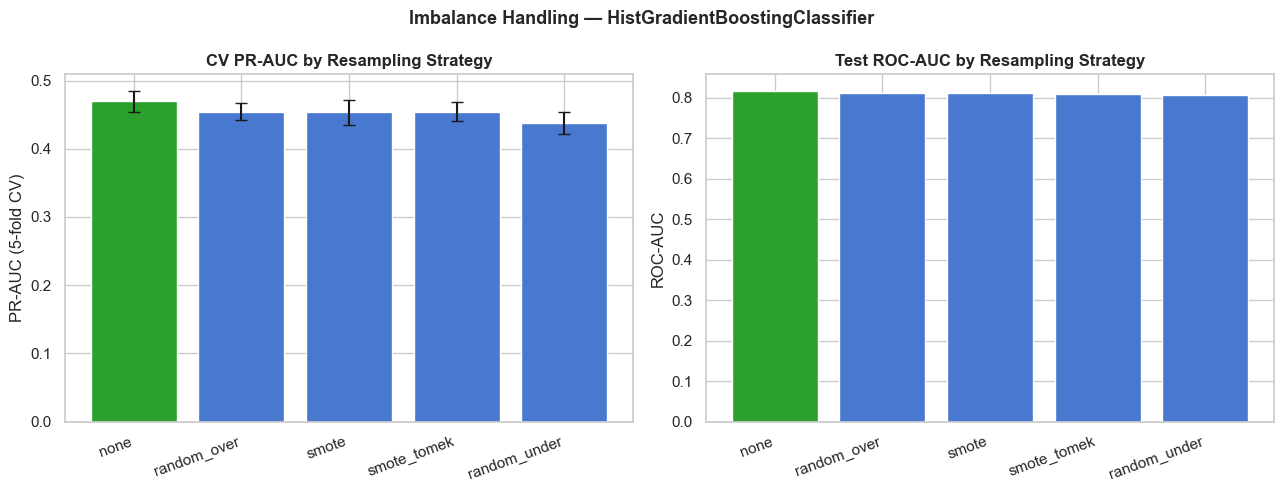


✓ Best resampling strategy: 'none'  →  Test PR-AUC = 0.4975


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from src.imbalance import build_imbalanced_pipeline

# ── Bar chart: CV PR-AUC comparison ──────────────────────────────────────────
valid = imbalance_df[imbalance_df["error"] == ""].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(valid))
bar_colors = ["#2ca02c" if v == valid["test_pr_auc"].max() else "#4878CF"
              for v in valid["test_pr_auc"]]

axes[0].bar(valid["strategy"], valid["cv_pr_auc_mean"],
            yerr=valid["cv_pr_auc_std"], capsize=4,
            color=bar_colors, edgecolor="white")
axes[0].set_title("CV PR-AUC by Resampling Strategy", fontweight="bold")
axes[0].set_ylabel("PR-AUC (5-fold CV)")
axes[0].set_xticklabels(valid["strategy"], rotation=20, ha="right")

axes[1].bar(valid["strategy"], valid["test_roc_auc"],
            color=bar_colors, edgecolor="white")
axes[1].set_title("Test ROC-AUC by Resampling Strategy", fontweight="bold")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_xticklabels(valid["strategy"], rotation=20, ha="right")

plt.suptitle(f"Imbalance Handling — {best_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

best_strategy = valid.loc[valid["test_pr_auc"].idxmax(), "strategy"]
best_pr = valid["test_pr_auc"].max()
print(f"\n✓ Best resampling strategy: {best_strategy!r}  →  Test PR-AUC = {best_pr:.4f}")

2026-05-17 03:49:32 | INFO     | src.imbalance | No resampling — building plain sklearn Pipeline.
2026-05-17 03:49:33 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='random_over'.
2026-05-17 03:49:35 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='smote'.
2026-05-17 03:49:38 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='smote_tomek'.
2026-05-17 03:49:44 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='random_under'.


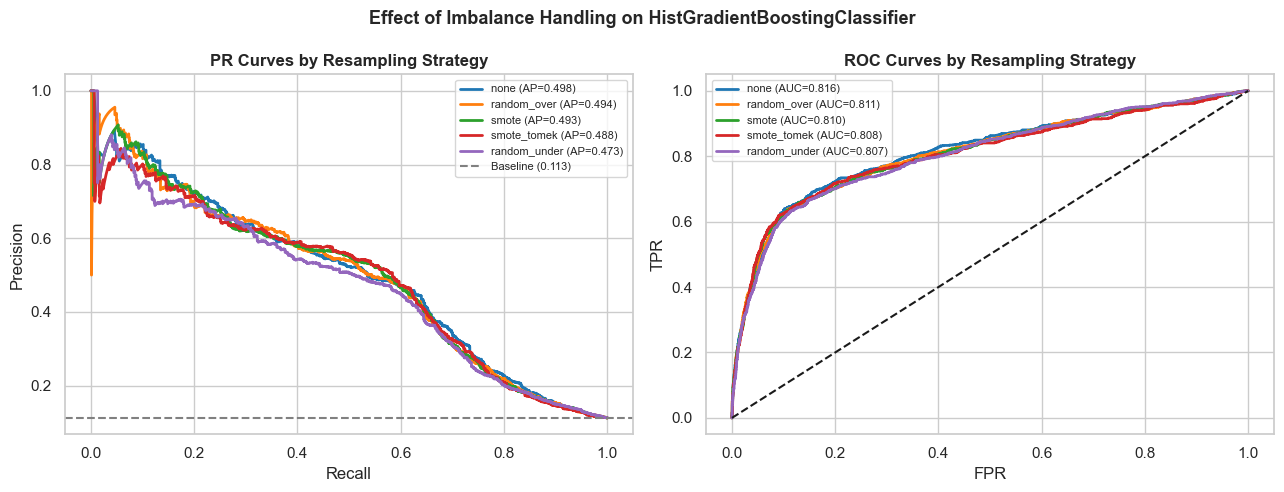

In [17]:
# ── PR curves: all strategies on test set ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for color, strat in zip(palette, valid["strategy"]):
    pipe = build_imbalanced_pipeline(
        clone(preprocessor_b),
        clone(best_base_model),
        strategy=strat,
        random_state=42,
    )
    pipe.fit(X_train_b, y_train_int)
    y_prob = pipe.predict_proba(X_test_b_imb)[:, 1]

    prec, rec, _ = precision_recall_curve(y_test_int, y_prob)
    ap = auc(rec, prec)
    axes[0].plot(rec, prec, color=color, lw=2, label=f"{strat} (AP={ap:.3f})")

    fpr, tpr, _ = roc_curve(y_test_int, y_prob)
    ra = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f"{strat} (AUC={ra:.3f})")

baseline_rate = y_test_int.mean()
axes[0].axhline(baseline_rate, color="gray", linestyle="--", label=f"Baseline ({baseline_rate:.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("PR Curves by Resampling Strategy", fontweight="bold")
axes[0].legend(fontsize=8)

axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curves by Resampling Strategy", fontweight="bold")
axes[1].legend(fontsize=8)

plt.suptitle(f"Effect of Imbalance Handling on {best_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
# ── Save the best resampled model ────────────────────────────────────────────
best_resampled_pipe = build_imbalanced_pipeline(
    clone(preprocessor_b),
    clone(best_base_model),
    strategy=best_strategy,
    random_state=42,
)
best_resampled_pipe.fit(X_train_b, y_train_int)

from src.modeling import save_model as _save
best_resampled_path = MODELS_DIR / f"best_model_set_b_{best_strategy}_resampled.joblib"
_save(best_resampled_pipe, best_resampled_path)
print(f"✓ Best resampled model saved → {best_resampled_path}")
print(f"  Strategy : {best_strategy}")
print(f"  Model    : {best_name}")
print(f"  PR-AUC   : {best_pr:.4f}")

2026-05-17 03:50:00 | INFO     | src.imbalance | No resampling — building plain sklearn Pipeline.
2026-05-17 03:50:01 | INFO     | src.modeling | Saved model → /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/models/best_model_set_b_none_resampled.joblib


✓ Best resampled model saved → /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/models/best_model_set_b_none_resampled.joblib
  Strategy : none
  Model    : HistGradientBoostingClassifier
  PR-AUC   : 0.4975
